# CCGT Gas Capex Analysis

Data source: Halcyon Gas Power Plant Tracker (17 July 2026), covering gas power plant projects across the US. We keep only CCGT projects with a reported cost ($/kW), then use regression analysis on that data to forecast CCGT capex from 2026 to 2032.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "runreeds.py").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

FORECAST_DIR = REPO_ROOT / "CEPM/preprocessing/gas_capex_forecast"

df = pd.read_csv(FORECAST_DIR / "Halcyon_July_CCGT.csv")
df.head()

,Plant / Unit Name,State,BA Code,Announcement Date,Planned / Operating Year,Technology Type,Capacity (MW),Cost ($/kW),CapEx ($M),Actual vs. Estimated Cost,Dollar Year,Latitude,Longitude,EIA Status,EIA Plant ID
0,Trumbull Energy Center,OH,PJM,"Mar 18, 2022",2026,Combined-Cycle Gas Turbine,940.0,"1,063.83","1,000.00",-,-,31.38203,-80.8525,66918,"Clean Energy Future - Trumbull, LLC."
1,Nemadji Trail Energy Center,WI,MISO,"Jan 22, 2019",2027,Combined-Cycle Gas Turbine,550.0,"1,116.00",700.00,Estimated,2020.0,-,-,-,-
2,Orange County Advanced Power Station,TX,MISO,"Sep 16, 2021",2026,Combined-Cycle Gas Turbine,1215.0,"1,300.41","1,580.00",Estimated,2023.0,30.025251,-93.87134,66621,Entergy Texas Inc.
3,Traceview Advanced Power Station,MS,MISO,"Sep 30, 2025",2029,Combined-Cycle Gas Turbine,754.0,"1,326.26","1,000.00",Estimated,2025.0,-,-,-,-
4,Lincoln Land Energy Center,IL,MISO,"Apr 25, 2025",2030,Combined-Cycle Gas Turbine,1100.0,"1,363.64","1,500.00",-,-,39.5788,-89.57984,62022,Lincoln Land Energy Center LLC


## Data Cleaning

Drop two types of outliers before fitting:
- Projects with a planned/operating year **after 2032** 
- Projects with a cost **above $3000/kW** 
This leaves 28 CCGT projects to work with.

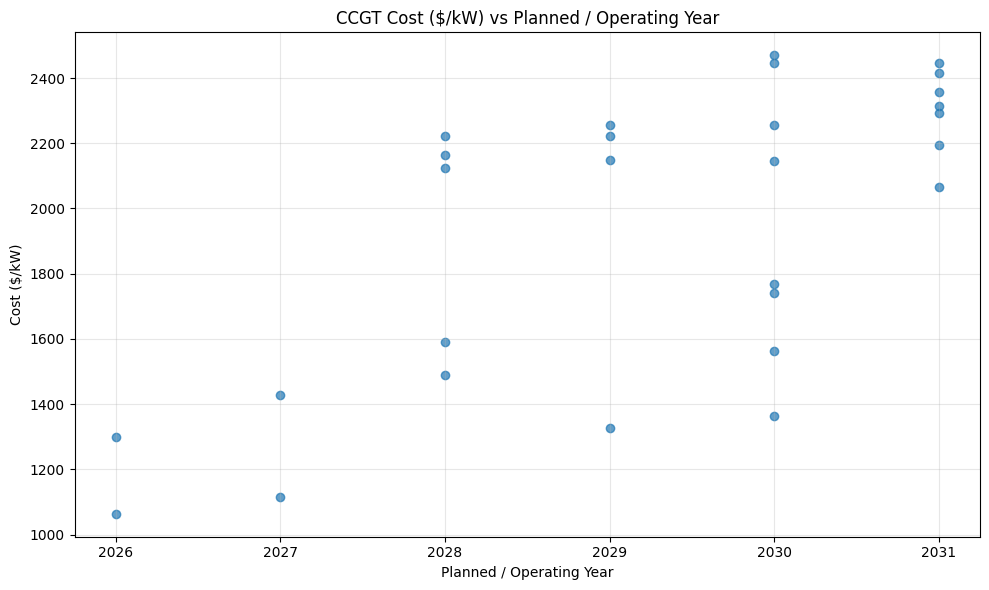

In [2]:
df["Cost ($/kW)"] = df["Cost ($/kW)"].astype(str).str.replace(",", "").astype(float)
df["Planned / Operating Year"] = pd.to_numeric(df["Planned / Operating Year"], errors="coerce")

# Clean data: drop rows with year after 2032 or cost above 3000 $/kW (outliers)
df = df[(df["Planned / Operating Year"] <= 2032) & (df["Cost ($/kW)"] <= 3000)]
df.shape

# Scatter plot: cost vs year 
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["Planned / Operating Year"], df["Cost ($/kW)"], alpha=0.7)
ax.set_xlabel("Planned / Operating Year")
ax.set_ylabel("Cost ($/kW)")
ax.set_title("CCGT Cost ($/kW) vs Planned / Operating Year")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

X_scaled = StandardScaler().fit_transform(df[["Planned / Operating Year", "Cost ($/kW)"]].values)
years = np.arange(2026, 2033)
colors = {0: "steelblue", 1: "tomato"}

Visually, we can see 2 groups of CCGT projects — one below and one above ~$1800/kW. `CCGT_clustering_methods.ipynb` tests several clustering methods (K-Means, hierarchical, DBSCAN) to see which one actually recovers this split.

## Regression on all data (no clustering)

We start with a single regression on **all 28 plants together**, with no clustering — this uses the full sample size and directly tests whether cost trends with year across the whole CCGT dataset. We compare this against a clustered approach (DBSCAN) further below.


CCGT (all data, no clustering) — 28 plants
  Year  : 2026–2031  (mean 2029.2)
  Cost  : $1064–$2470 /kW  (mean $1939, std $449)
  Regression: slope=192.8 $/kW/yr,  R²=0.447,  p=0.000


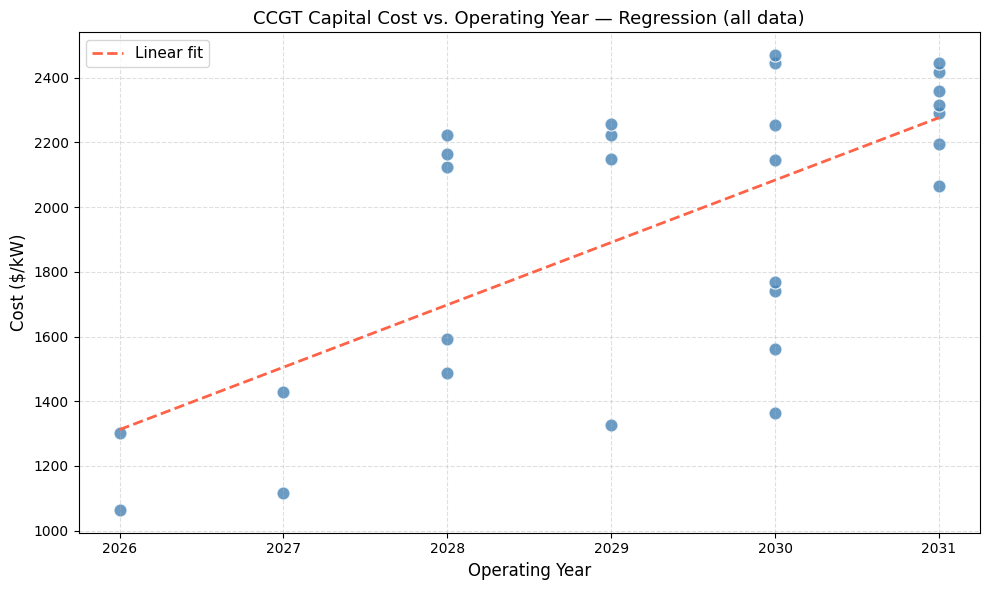

In [3]:
slope_all, intercept_all, r_all, p_all, stderr_all = linregress(df["Planned / Operating Year"], df["Cost ($/kW)"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["Planned / Operating Year"], df["Cost ($/kW)"],
           color="steelblue", alpha=0.8, edgecolors="white", s=90)

x_range = np.linspace(df["Planned / Operating Year"].min(), df["Planned / Operating Year"].max(), 100)
ax.plot(x_range, intercept_all + slope_all * x_range,
        color="tomato", linewidth=2, linestyle="--", label="Linear fit")

print(f"\nCCGT (all data, no clustering) — {len(df)} plants")
print(f"  Year  : {df['Planned / Operating Year'].min():.0f}–{df['Planned / Operating Year'].max():.0f}  (mean {df['Planned / Operating Year'].mean():.1f})")
print(f"  Cost  : ${df['Cost ($/kW)'].min():.0f}–${df['Cost ($/kW)'].max():.0f} /kW  (mean ${df['Cost ($/kW)'].mean():.0f}, std ${df['Cost ($/kW)'].std():.0f})")
print(f"  Regression: slope={slope_all:.1f} $/kW/yr,  R²={r_all**2:.3f},  p={p_all:.3f}")

ax.set_xlabel("Operating Year", fontsize=12)
ax.set_ylabel("Cost ($/kW)", fontsize=12)
ax.set_title("CCGT Capital Cost vs. Operating Year — Regression (all data)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [4]:
# Extract regression statistics (all data)
regression_stats_all = pd.DataFrame([{
    "n_plants": len(df),
    "slope_$/kW_per_yr": slope_all,
    "intercept_$/kW": intercept_all,
    "r_squared": r_all**2,
    "p_value": p_all,
    "std_err": stderr_all,
}])
regression_stats_all

,n_plants,slope_$/kW_per_yr,intercept_$/kW,r_squared,p_value,std_err
0,28,192.825977,-389353.217422,0.446582,0.000102,42.097366


- **p-value = 0.0001** << 0.05, so this trend **is statistically significant**
- **std_err = 42.1** — the slope's uncertainty is much smaller relative to the slope itself (42 vs. 193) than it was for either cluster

In [5]:
# Regression forecast 2026-2032 (all data)
forecast_all = pd.DataFrame({
    "Year": years,
    "Cost_$/kW": np.round(intercept_all + slope_all * years, 1),
})
forecast_all

,Year,Cost_$/kW
0,2026,1312.2
1,2027,1505.0
2,2028,1697.9
3,2029,1890.7
4,2030,2083.5
5,2031,2276.3
6,2032,2469.2


## Clustering (DBSCAN) + regression per cluster

After comparing different clustering methods (see `CCGT_clustering_methods.ipynb`), DBSCAN was selected as the one that best recovers the 2 cost groups. We use it here to split the data, then fit a regression on each cluster — the point of doing this per cluster (rather than on all data) is to get a **low-cost** and a **high-cost** scenario for the CCGT capex forecast, instead of a single average trend.

In [6]:
from sklearn.cluster import DBSCAN

best_params = None
for min_samples in [3, 4, 5]:
    for eps in np.arange(0.2, 1.5, 0.05):
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        if n_clusters == 2 and n_noise == 0:
            best_params = (eps, min_samples)
            break
    if best_params:
        break

print(f"Selected DBSCAN params: eps={best_params[0]:.2f}, min_samples={best_params[1]}")
df["Cluster_dbscan"] = DBSCAN(eps=best_params[0], min_samples=best_params[1]).fit_predict(X_scaled)
df["Cluster_dbscan"].value_counts()

Selected DBSCAN params: eps=0.80, min_samples=3


Cluster_dbscan
1    17
0    11
Name: count, dtype: int64


Cluster 0 — 11 plants
  Year  : 2026–2030  (mean 2028.3)
  Cost  : $1064–$1768 /kW  (mean $1432, std $229)
  Regression: slope=100.4 $/kW/yr,  R²=0.505,  p=0.014

Cluster 1 — 17 plants
  Year  : 2028–2031  (mean 2029.9)
  Cost  : $2067–$2470 /kW  (mean $2267, std $125)
  Regression: slope=44.6 $/kW/yr,  R²=0.175,  p=0.095


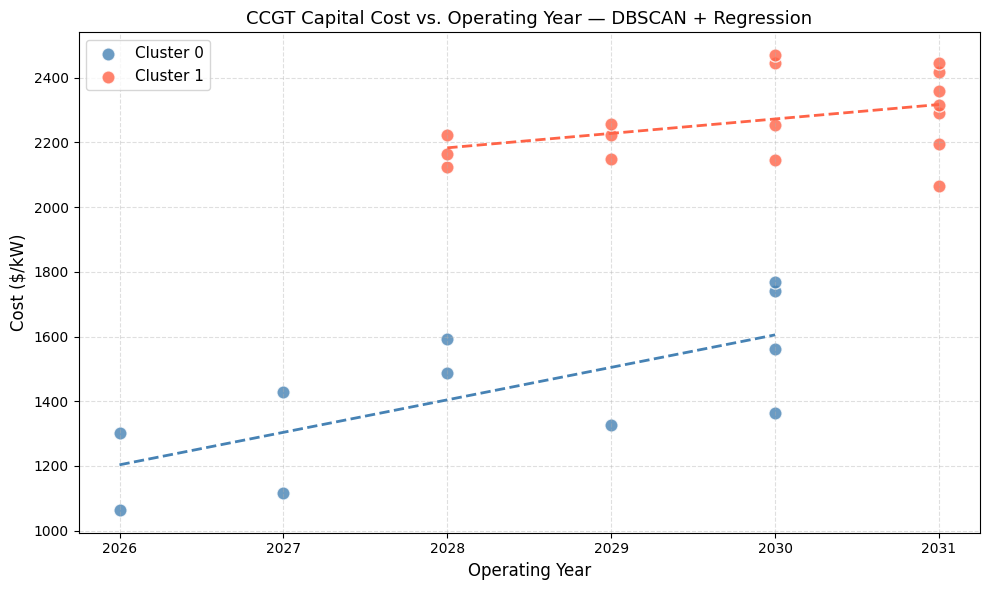

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

for c, grp in df.groupby("Cluster_dbscan"):
    ax.scatter(grp["Planned / Operating Year"], grp["Cost ($/kW)"],
               color=colors[c], label=f"Cluster {c}",
               alpha=0.8, edgecolors="white", s=90)

    slope, intercept, r, p, _ = linregress(grp["Planned / Operating Year"], grp["Cost ($/kW)"])

    x_range = np.linspace(grp["Planned / Operating Year"].min(), grp["Planned / Operating Year"].max(), 100)
    ax.plot(x_range, intercept + slope * x_range,
            color=colors[c], linewidth=2, linestyle="--")

    print(f"\nCluster {c} — {len(grp)} plants")
    print(f"  Year  : {grp['Planned / Operating Year'].min():.0f}–{grp['Planned / Operating Year'].max():.0f}  (mean {grp['Planned / Operating Year'].mean():.1f})")
    print(f"  Cost  : ${grp['Cost ($/kW)'].min():.0f}–${grp['Cost ($/kW)'].max():.0f} /kW  (mean ${grp['Cost ($/kW)'].mean():.0f}, std ${grp['Cost ($/kW)'].std():.0f})")
    print(f"  Regression: slope={slope:.1f} $/kW/yr,  R²={r**2:.3f},  p={p:.3f}")

ax.set_xlabel("Operating Year", fontsize=12)
ax.set_ylabel("Cost ($/kW)", fontsize=12)
ax.set_title("CCGT Capital Cost vs. Operating Year — DBSCAN + Regression", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [8]:
# Extract regression statistics per DBSCAN cluster
stats_rows = []
for c, grp in df.groupby("Cluster_dbscan"):
    slope, intercept, r, p, stderr = linregress(grp["Planned / Operating Year"], grp["Cost ($/kW)"])
    stats_rows.append({
        "Cluster": c,
        "n_plants": len(grp),
        "slope_$/kW_per_yr": slope,
        "intercept_$/kW": intercept,
        "r_squared": r**2,
        "p_value": p,
        "std_err": stderr,
    })

regression_stats_dbscan = pd.DataFrame(stats_rows)
regression_stats_dbscan

,Cluster,n_plants,slope_$/kW_per_yr,intercept_$/kW,r_squared,p_value,std_err
0,0,11,100.409444,-202226.115000,0.505279,0.014204,33.118300
1,1,17,44.625676,-88317.739189,0.174727,0.094986,25.041363


**Regression results per cluster**:

- **Cluster 0 (n=11, low-cost tier)**: slope=+$100.4/kW/yr, R²=0.505, **p=0.014 — statistically significant**, a fairly strong fit.
- **Cluster 1 (n=17, high-cost tier)**: slope=+$44.6/kW/yr, R²=0.175, p=0.095 — not significant at the usual 0.05 threshold, and a weaker fit.

We export its per-cluster forecast below, alongside the all-data (no clustering) forecast kept from earlier.

In [9]:
# Regression values 2026-2032 (per DBSCAN cluster)
rows = {"Year": years}
for c, grp in df.groupby("Cluster_dbscan"):
    slope, intercept, _, _, _ = linregress(grp["Planned / Operating Year"], grp["Cost ($/kW)"])
    rows[f"Cluster_{c}_cost_$/kW"] = np.round(intercept + slope * years, 1)

forecast_dbscan = pd.DataFrame(rows)
forecast_dbscan

,Year,Cluster_0_cost_$/kW,Cluster_1_cost_$/kW
0,2026,1203.4,2093.9
1,2027,1303.8,2138.5
2,2028,1404.2,2183.1
3,2029,1504.6,2227.8
4,2030,1605.1,2272.4
5,2031,1705.5,2317.0
6,2032,1805.9,2361.6


In [10]:
# Combine DBSCAN per-cluster forecast with the all-data forecast, and save for reuse (e.g. gas_CAPEX_update.ipynb)
combined_forecast = forecast_dbscan.merge(
    forecast_all.rename(columns={"Cost_$/kW": "AllData_cost_$/kW"}),
    on="Year",
)
combined_forecast.to_csv(FORECAST_DIR / "ccgt_regression_forecast.csv", index=False)
combined_forecast

,Year,Cluster_0_cost_$/kW,Cluster_1_cost_$/kW,AllData_cost_$/kW
0,2026,1203.4,2093.9,1312.2
1,2027,1303.8,2138.5,1505.0
2,2028,1404.2,2183.1,1697.9
3,2029,1504.6,2227.8,1890.7
4,2030,1605.1,2272.4,2083.5
5,2031,1705.5,2317.0,2276.3
6,2032,1805.9,2361.6,2469.2


Putting this together, the DBSCAN clusters give us two scenarios — **Cluster 0 = low-cost scenario**, **Cluster 1 = high-cost scenario** — while the all-data regression (no clustering) serves as a **mid/reference scenario**, since it's fit on the full sample without splitting into cost tiers. The notebook `gas_CAPEX_update.ipynb` then uses these three forecasts to generate separate ATB input CSV files for each scenario.